<a href="https://colab.research.google.com/github/Mandira124/Machine-Learning-Beginner-Projects/blob/main/Regularization%26Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Practical 3: Regularization & Optimization

- Assignment: Practical 3 – Regularization & Optimization
- Student: Mandira Sharma
- Date: 4/19/2026
- Dataset: Fashion‑MNIST (PyTorch)

### Objective

- Train a CNN on Fashion‑MNIST for image classification.
- Show overfitting using a baseline model without regularization.
- Apply L2 regularization and dropout and compare with baseline.
- Compare SGD and Adam optimizers.
- Analyze train vs validation loss/accuracy and discuss generalization.

### Background

Overfitting happens when a model fits the training data very well but performs worse on unseen data, often visible as decreasing training loss but flat or increasing validation loss. Regularization methods restrict model complexity to improve generalization.

L2 regularization (weight decay) adds a penalty on large weights to the loss, keeping parameters small and smoothing the model. Dropout randomly sets a fraction of activations to zero during training, forcing the network to not rely too much on any single neuron and reducing overfitting.

SGD updates parameters using gradients with a fixed learning rate and can generalize well but may converge slowly. Adam adapts learning rates per parameter using gradient history and usually converges faster but sometimes overfits more without regularization.

### Dataset

- Fashion‑MNIST: clothing images (grayscale, 28×28, 10 classes).
- 60,000 training images, 10,000 test images.
- Here: 50,000 train, 10,000 validation (split from train), 10,000 test.

### Baseline model

For all experiments, I used the same convolutional neural network (CNN) architecture as a baseline. The only things I changed between experiments were the optimizer (SGD vs Adam) and the regularization settings (none, L2, dropout).

The baseline model has:

- **Input:** 28×28 grayscale Fashion‑MNIST images (1 channel).
- **Convolutional feature extractor:**
  - Conv layer 1: 1 → 32 channels, kernel size 3×3, padding 1, activation ReLU.
  - Max pooling 1: 2×2, which reduces the feature map size from 28×28 to 14×14.
  - Conv layer 2: 32 → 64 channels, kernel size 3×3, padding 1, activation ReLU.
  - Max pooling 2: 2×2, which reduces the feature map size from 14×14 to 7×7.
- **Fully connected classifier:**
  - Flatten: converts the 64×7×7 feature maps into a 1D vector.
  - Linear layer 1: 64·7·7 → 128 units, activation ReLU.
  - Linear layer 2: 128 → 10 units (one for each Fashion‑MNIST class), used with cross‑entropy loss.

In the **baseline (no regularization)**:

- There is **no dropout** layer enabled.
- L2 regularization is disabled by setting (weight_decay = 0.0) in the optimizer.
- The model is trained for 15 epochs with batch size 128.

This baseline model is deliberately simple but expressive enough to reach high training accuracy on Fashion‑MNIST. Because it has no explicit regularization, it tends to overfit: training loss and accuracy improve continuously, while validation curves start to plateau or diverge. The regularized models (with L2 or dropout) are built from exactly the same architecture, so any differences in performance come from the choice of optimizer and regularization, not from changing the model structure.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_size = 50000
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Using device: cuda


100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.12MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.9MB/s]


Train samples: 50000
Val samples: 10000
Test samples: 10000


In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, use_dropout=False, dropout_p=0.5):
        super(SimpleCNN, self).__init__()
        self.use_dropout = use_dropout

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        x = self.fc2(x)
        return x

In [3]:
def train_one_epoch(model, optimizer, criterion, dataloader, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, criterion, dataloader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

### Regularization settings used

#### 1. No regularization

In the **no regularization** setting, the model is trained without any extra penalties or noise added to the weights or activations.  
- There is **no L1** or L2 penalty added to the loss.  
- There is **no dropout** layer active (all neurons are always used).  

This allows the network to freely adjust its weights to fit the training data as much as possible. The advantage is that the model can reach very low training loss and very high training accuracy. The disadvantage is that it can easily **overfit**, meaning it memorizes details of the training data and performs worse on the validation and test sets.

#### 2. L2 regularization (weight decay)

**L2 regularization** adds a penalty to the loss function that grows with the **square of the weight values**.  
In practice, in the optimizer we use a parameter called (weight_decay) to control the strength of L2 regularization.

- Concept: the total loss becomes  
  > total loss = original loss + λ × (sum of squared weights)  

- Effect:  
  - Pushes the weights to stay **small** (but usually not exactly zero).  
  - Prevents any single weight from becoming very large and dominating the prediction.  
  - Makes the model smoother and less sensitive to small changes in the input.  

In our experiments, we used (weight_decay = 1e-4) as a mild L2 regularization value. This slightly reduced training accuracy but **reduced overfitting**, making training and validation curves closer and improving the stability of test performance.

#### 3. Dropout

**Dropout** is a regularization technique that randomly “drops” (sets to zero) a fraction of neuron outputs during training.

- During training:
  - For each mini‑batch, some neurons in the chosen layer are randomly turned off with probability p (e.g., (p = 0.5) means half of them are dropped on average).
  - The remaining neurons must learn to perform well even when some of their neighbors are missing.

- During evaluation (validation/test):
  - Dropout is **disabled** and all neurons are used, but their outputs are scaled appropriately by the framework so that the overall magnitude stays consistent.

Effects:

- The network cannot rely too heavily on any single neuron or path.
- This reduces **co‑adaptation** (neurons working only in very specific combinations).
- It tends to reduce overfitting and improve generalization, at the cost of:
  - Lower training accuracy (because the task is harder during training).
  - Slightly noisier loss curves.

In our experiments, we used dropout with probability (p = 0.5) in the fully connected layer. This configuration produced smaller gaps between training and validation curves and gave the best test accuracy when combined with Adam, showing strong regularization benefits.

In [4]:
def run_experiment(use_dropout=False,
                   weight_decay=0.0,
                   optimizer_name="sgd",
                   num_epochs=15,
                   lr=0.01,
                   dropout_p=0.5):
    model = SimpleCNN(use_dropout=use_dropout, dropout_p=dropout_p).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(),
                              lr=lr,
                              momentum=0.9,
                              weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(),
                               lr=lr,
                               weight_decay=weight_decay)
    else:
        raise ValueError("Unknown optimizer")

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader, device)
        val_loss, val_acc = evaluate(model, criterion, val_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    test_loss, test_acc = evaluate(model, criterion, test_loader, device)
    print(f"Final Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc
    }
    return model, history


def plot_history(history, title_prefix=""):
    epochs = range(1, len(history["train_losses"]) + 1)

    plt.figure(figsize=(10, 3.5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_losses"], label="Train")
    plt.plot(epochs, history["val_losses"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accs"], label="Train")
    plt.plot(epochs, history["val_accs"], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [5]:
experiment_results = []
num_epochs = 15

# baseline: no regularization
model_base_sgd, hist_base_sgd = run_experiment(
    use_dropout=False,
    weight_decay=0.0,
    optimizer_name="sgd",
    num_epochs=num_epochs,
    lr=0.01
)
experiment_results.append({
    "name": "Baseline",
    "optimizer": "SGD",
    "regularization": "None",
    "test_acc": hist_base_sgd["test_acc"],
    "test_loss": hist_base_sgd["test_loss"]
})

model_base_adam, hist_base_adam = run_experiment(
    use_dropout=False,
    weight_decay=0.0,
    optimizer_name="adam",
    num_epochs=num_epochs,
    lr=0.001
)
experiment_results.append({
    "name": "Baseline",
    "optimizer": "Adam",
    "regularization": "None",
    "test_acc": hist_base_adam["test_acc"],
    "test_loss": hist_base_adam["test_loss"]
})

# L2
model_l2_sgd, hist_l2_sgd = run_experiment(
    use_dropout=False,
    weight_decay=1e-4,
    optimizer_name="sgd",
    num_epochs=num_epochs,
    lr=0.01
)
experiment_results.append({
    "name": "L2 (1e-4)",
    "optimizer": "SGD",
    "regularization": "L2",
    "test_acc": hist_l2_sgd["test_acc"],
    "test_loss": hist_l2_sgd["test_loss"]
})

model_l2_adam, hist_l2_adam = run_experiment(
    use_dropout=False,
    weight_decay=1e-4,
    optimizer_name="adam",
    num_epochs=num_epochs,
    lr=0.001
)
experiment_results.append({
    "name": "L2 (1e-4)",
    "optimizer": "Adam",
    "regularization": "L2",
    "test_acc": hist_l2_adam["test_acc"],
    "test_loss": hist_l2_adam["test_loss"]
})

# Dropout
model_do_sgd, hist_do_sgd = run_experiment(
    use_dropout=True,
    weight_decay=0.0,
    optimizer_name="sgd",
    num_epochs=num_epochs,
    lr=0.01,
    dropout_p=0.5
)
experiment_results.append({
    "name": "Dropout (0.5)",
    "optimizer": "SGD",
    "regularization": "Dropout",
    "test_acc": hist_do_sgd["test_acc"],
    "test_loss": hist_do_sgd["test_loss"]
})

model_do_adam, hist_do_adam = run_experiment(
    use_dropout=True,
    weight_decay=0.0,
    optimizer_name="adam",
    num_epochs=num_epochs,
    lr=0.001,
    dropout_p=0.5
)
experiment_results.append({
    "name": "Dropout (0.5)",
    "optimizer": "Adam",
    "regularization": "Dropout",
    "test_acc": hist_do_adam["test_acc"],
    "test_loss": hist_do_adam["test_loss"]
})

Epoch 1/15 | Train Loss: 0.6700, Val Loss: 0.4252, Train Acc: 0.7597, Val Acc: 0.8449
Epoch 2/15 | Train Loss: 0.3845, Val Loss: 0.3311, Train Acc: 0.8603, Val Acc: 0.8778
Epoch 3/15 | Train Loss: 0.3242, Val Loss: 0.3220, Train Acc: 0.8834, Val Acc: 0.8839
Epoch 4/15 | Train Loss: 0.2960, Val Loss: 0.2810, Train Acc: 0.8923, Val Acc: 0.8981
Epoch 5/15 | Train Loss: 0.2702, Val Loss: 0.2682, Train Acc: 0.9018, Val Acc: 0.9009
Epoch 6/15 | Train Loss: 0.2556, Val Loss: 0.2585, Train Acc: 0.9064, Val Acc: 0.9047
Epoch 7/15 | Train Loss: 0.2369, Val Loss: 0.2570, Train Acc: 0.9128, Val Acc: 0.9071
Epoch 8/15 | Train Loss: 0.2250, Val Loss: 0.2420, Train Acc: 0.9188, Val Acc: 0.9111
Epoch 9/15 | Train Loss: 0.2132, Val Loss: 0.2403, Train Acc: 0.9217, Val Acc: 0.9103
Epoch 10/15 | Train Loss: 0.2016, Val Loss: 0.2314, Train Acc: 0.9265, Val Acc: 0.9156
Epoch 11/15 | Train Loss: 0.1917, Val Loss: 0.2244, Train Acc: 0.9300, Val Acc: 0.9184
Epoch 12/15 | Train Loss: 0.1802, Val Loss: 0.2161, 

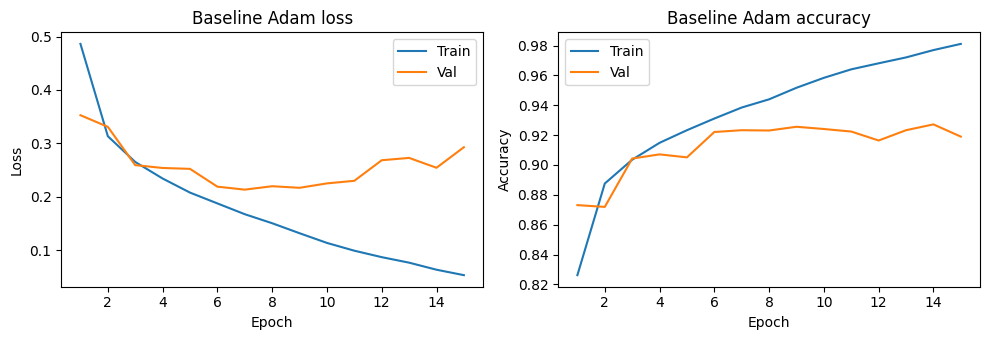

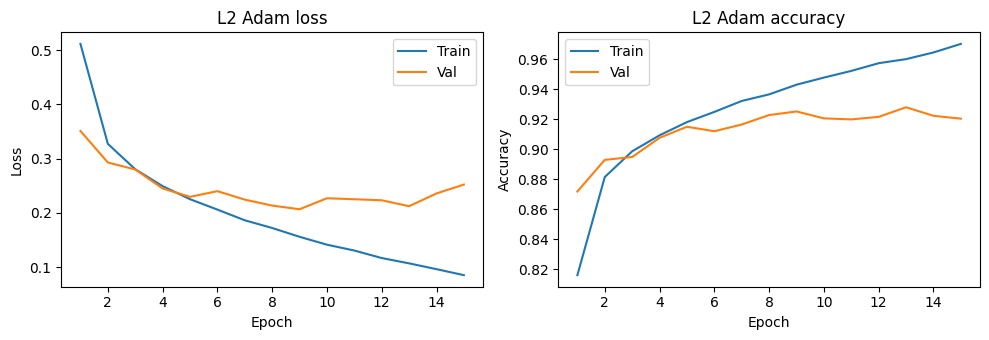

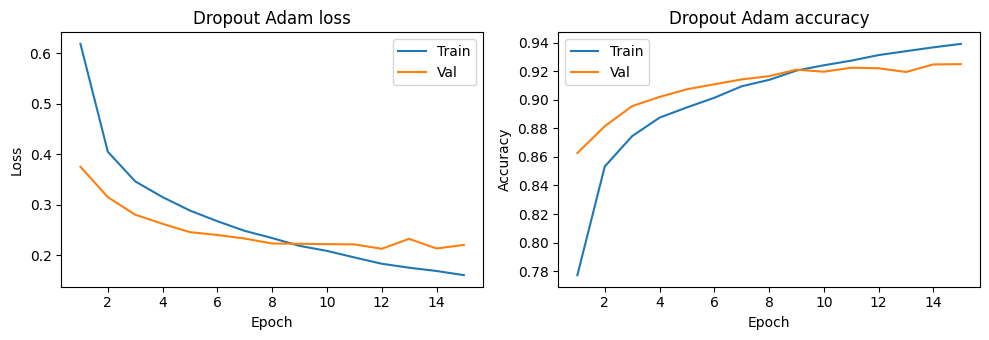

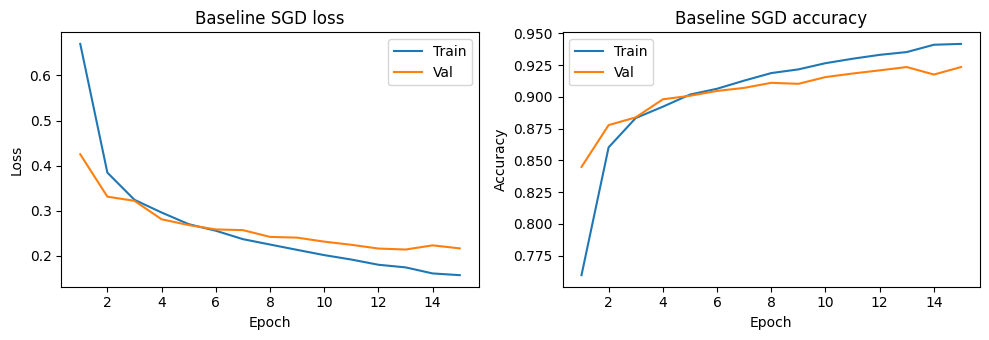

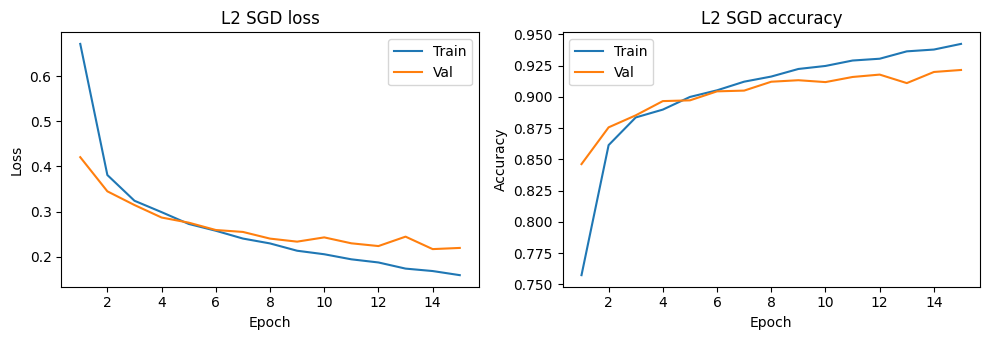

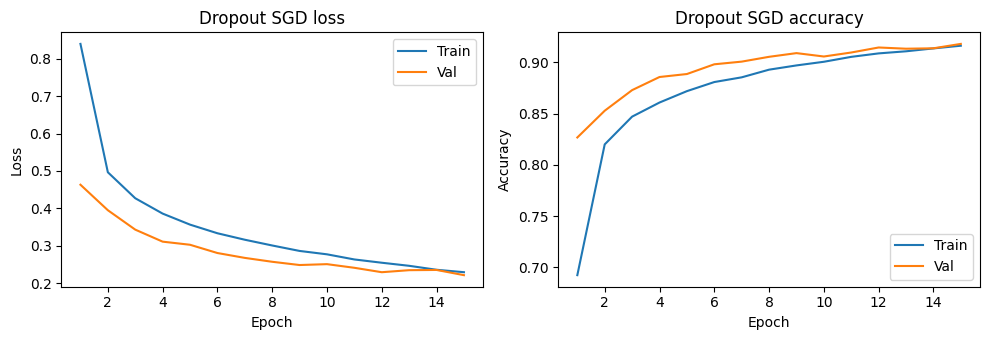

Config          Optimizer  Regularization Test Acc   Test Loss 
-----------------------------------------------------------------
Baseline        SGD        None          0.9138    0.2448
Baseline        Adam       None          0.9156    0.3391
L2 (1e-4)       SGD        L2            0.9120    0.2540
L2 (1e-4)       Adam       L2            0.9142    0.2834
Dropout (0.5)   SGD        Dropout       0.9100    0.2484
Dropout (0.5)   Adam       Dropout       0.9204    0.2519


In [6]:
# plots to show overfitting and effect of regularization
plot_history(hist_base_adam, "Baseline Adam")
plot_history(hist_l2_adam, "L2 Adam")
plot_history(hist_do_adam, "Dropout Adam")

plot_history(hist_base_sgd, "Baseline SGD")
plot_history(hist_l2_sgd, "L2 SGD")
plot_history(hist_do_sgd, "Dropout SGD")

# auto summary table
print("{:<15} {:<10} {:<13} {:<10} {:<10}".format(
    "Config", "Optimizer", "Regularization", "Test Acc", "Test Loss"
))
print("-" * 65)
for exp in experiment_results:
    print("{:<15} {:<10} {:<13} {:.4f}    {:.4f}".format(
        exp["name"],
        exp["optimizer"],
        exp["regularization"],
        exp["test_acc"],
        exp["test_loss"]
    ))

### Results and observations

- Overall, the best-performing configuration was **Adam with dropout (p = 0.5)**, which achieved the highest test accuracy (0.9204) with a relatively low test loss (0.2519). This indicates strong generalization for this model–dataset setup.

- Comparing **baseline vs regularized models**, we see that regularization (L2 or dropout) does **not guarantee** better test performance on every dataset and for every optimizer. In our case, the baseline SGD model without regularization (test acc ≈ 0.9138) slightly outperformed the SGD models with L2 and dropout, while for Adam the combination with dropout clearly improved generalization over the unregularized baseline.

- Looking at the **train–validation gaps**, the most overfitted runs are the ones where training accuracy becomes very high (up to 98%) while validation accuracy saturates around 92–93% and validation loss starts to increase. Runs with L2 and especially dropout tend to keep the train and validation curves closer, which is a sign of reduced overfitting, even if the final test accuracy is sometimes similar.

- These results illustrate that **regularization trades a bit of training accuracy for better behavior on unseen data**, but its benefit depends on the model capacity, optimizer, dataset, and strength of the regularization. It helps control overfitting, but it does not mathematically guarantee that every regularized model will always outperform the non-regularized one.

- In conclusion, for this experiment:  
  - **Best generalization overall:** Adam + dropout (p = 0.5).  
  - **SGD:** baseline (no regularization) already generalizes well on Fashion-MNIST, so extra regularization only slightly changes test accuracy.  
  - **Adam:** needs regularization (especially dropout) to avoid strong overfitting and achieve its best test performance.